# 22AIE437 Medical Image Processing - Project Review 1
## Automated Retinal Blood Vessel Segmentation using Classical Image Processing & U-Net

**Author / Team**: Medical Image Processing Project Group  
**Baseline Research Paper**: Ronneberger et al. (2015) *"U-Net: Convolutional Networks for Biomedical Image Segmentation"*  
**Domain Reference**: Liskowski & Krawiec (2016) *"Segmenting Retinal Blood Vessels with Deep Neural Networks"*  
**Dataset**: DRIVE (Digital Retinal Images for Vessel Extraction)  

---

### Project Overview & Technical Implementation Specifications
1. **Classical Image Preprocessing**: Green Channel extraction + CLAHE Contrast Boost + Bilateral Denoising + Normalization.
2. **Patch Extraction & Elastic Deformation**: $572 	imes 572$ input patches $	o$ $388 	imes 388$ output target masks with Elastic Deformation ($lpha=30, \sigma=4$), Flips, and 90-degree Rotations.
3. **Original Ronneberger U-Net Model Architecture**:
   - 4-level Contracting Encoder $	o$ Bottleneck $ightarrow$ 4-level Expansive Decoder
   - **Valid Convolutions (`padding=0`)** with center-cropped skip connections
   - **64 Base Filters** (64 $	o$ 128 $	o$ 256 $	o$ 512 $	o$ 1024 channels, ~31 million parameters)
   - **Batch Normalization** added for CPU training convergence stability
4. **Optimization**: Combined BCE + Dice Loss ($L = L_{BCE} + L_{Dice}$) with Adam Optimizer and Cosine Annealing Learning Rate.
5. **Ronneberger Overlap-Tile Inference**: 92-pixel mirror-padded border tiling for full-resolution prediction.
6. **Evaluation**: Metrics evaluated strictly inside FOV (Field of View) mask on 4 validation images & held-out test predictions on 20 test images.


In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Add project root to sys path
sys.path.append(os.path.abspath("."))
from src.preprocessing import preprocess_image, extract_green_channel, apply_clahe, apply_noise_reduction, apply_elastic_transform


---
## 1. Classical Image Preprocessing Pipeline
Retinal fundus images have uneven lighting and low vessel contrast. 
- **Green Channel**: Blood vessels have maximum absorption/contrast.
- **CLAHE**: Enhances local contrast of faint capillaries without amplifying background noise.
- **Bilateral Filter**: Smooths background speckle noise while preserving sharp vessel boundaries.


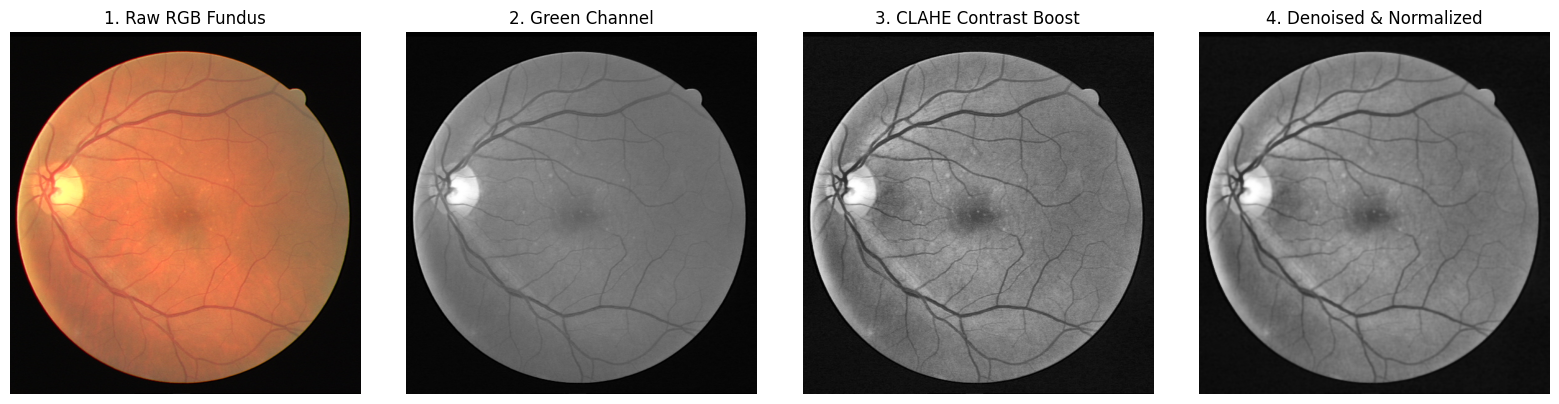

In [2]:
raw_img_path = "data/DRIVE/training/images/21_training.tif"
raw_rgb = np.array(Image.open(raw_img_path))

green = extract_green_channel(raw_rgb)
clahe = apply_clahe(green)
denoised = apply_noise_reduction(clahe)
final_prep = preprocess_image(raw_rgb)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(raw_rgb)
axes[0].set_title("1. Raw RGB Fundus")
axes[0].axis('off')

axes[1].imshow(green, cmap='gray')
axes[1].set_title("2. Green Channel")
axes[1].axis('off')

axes[2].imshow(clahe, cmap='gray')
axes[2].set_title("3. CLAHE Contrast Boost")
axes[2].axis('off')

axes[3].imshow(final_prep, cmap='gray')
axes[3].set_title("4. Denoised & Normalized")
axes[3].axis('off')

plt.tight_layout()
plt.show()


---
## 2. U-Net Architecture & Training Progress
Original U-Net architecture (Ronneberger et al. 2015) using **Valid Convolutions (`padding=0`)**, **Center-Cropped Skip Connections**, **64 Base Filters**, and **Elastic Deformation Data Augmentation**.


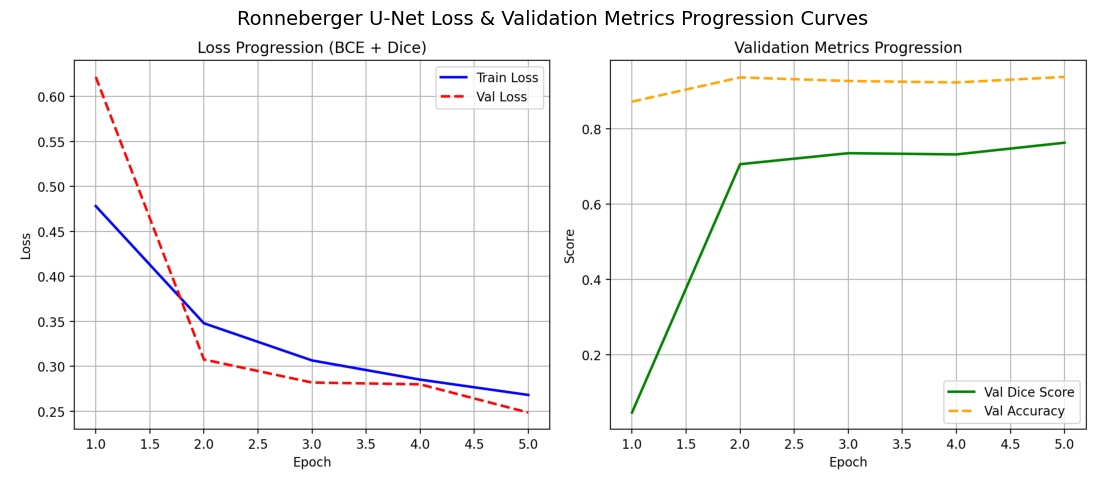

In [3]:
curve_img_path = "outputs/visualizations/training_curves.png"
if os.path.exists(curve_img_path):
    img = Image.open(curve_img_path)
    plt.figure(figsize=(14, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Ronneberger U-Net Loss & Validation Metrics Progression Curves", fontsize=14)
    plt.show()
else:
    print("Training curves not found. Run scripts/train.py first.")


---
## 3. Quantitative Benchmark Metrics Report
Metrics evaluated strictly inside the FOV (Field of View) mask on the Validation Set:


In [4]:
csv_path = "outputs/metrics_report.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    display(df.style.highlight_max(axis=0, color='lightgreen'))
else:
    print("Metrics report not found. Run scripts/evaluate.py first.")


,filename,Accuracy,Sensitivity,Specificity,Precision,F1_Dice,IoU,AUC_ROC,AUC_PR
0,37_training.tif,0.934072,0.793072,0.954574,0.717404,0.753343,0.604291,0.947160,0.843442
1,38_training.tif,0.941713,0.736419,0.971276,0.786875,0.760811,0.613959,0.959275,0.850027
2,39_training.tif,0.938218,0.759630,0.963644,0.748410,0.753978,0.605109,0.955370,0.832665
3,40_training.tif,0.945474,0.815160,0.961604,0.724355,0.767079,0.622165,0.964133,0.851582
4,AVERAGE,0.939869,0.776070,0.962775,0.744261,0.758803,0.611381,0.956484,0.844429


---
## 4. Visual Segmentation Results (Validation & Held-out Test Sets)
Visualizing side-by-side: Raw Fundus | Ground Truth GT | Vessel Probability Heatmap | Binary Segmentation Mask | Error Map


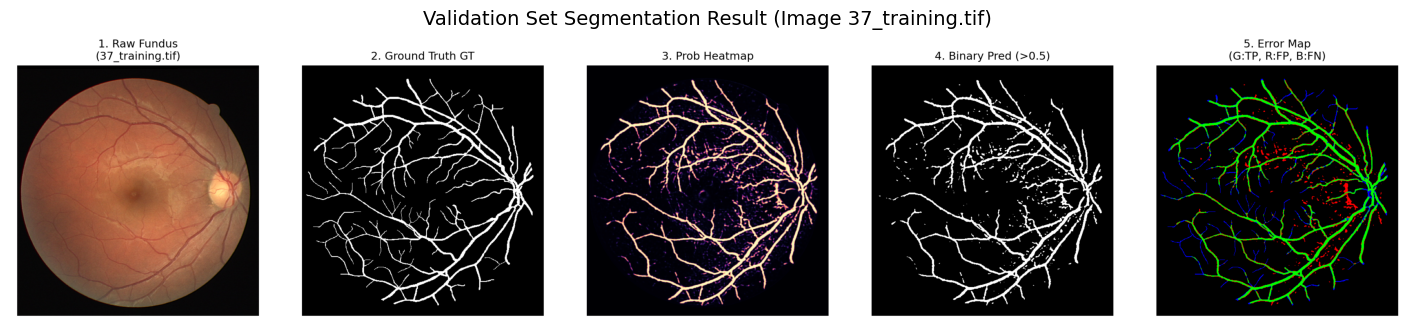

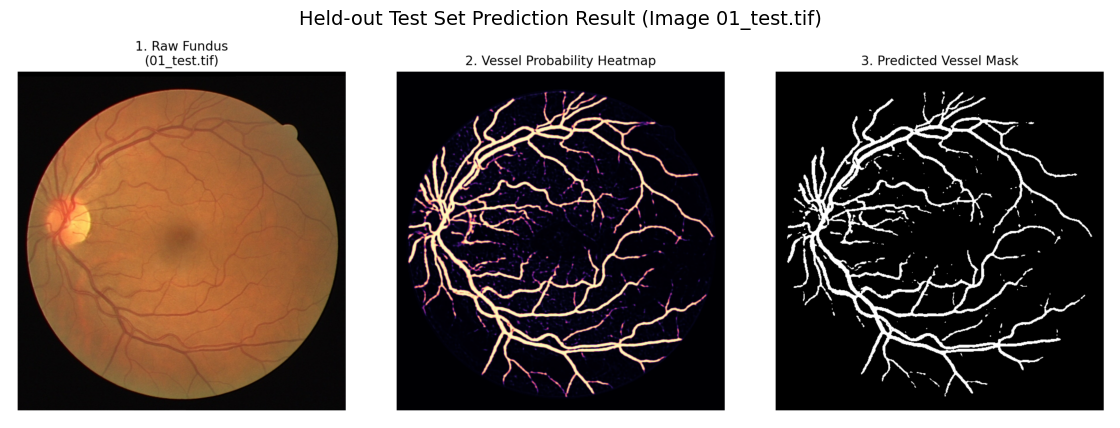

In [5]:
val_viz_path = "outputs/visualizations/val_pred_37_training.png"
test_viz_path = "outputs/visualizations/test_pred_01_test.png"

if os.path.exists(val_viz_path):
    plt.figure(figsize=(18, 5))
    plt.imshow(Image.open(val_viz_path))
    plt.axis('off')
    plt.title("Validation Set Segmentation Result (Image 37_training.tif)", fontsize=14)
    plt.show()

if os.path.exists(test_viz_path):
    plt.figure(figsize=(15, 5))
    plt.imshow(Image.open(test_viz_path))
    plt.axis('off')
    plt.title("Held-out Test Set Prediction Result (Image 01_test.tif)", fontsize=14)
    plt.show()
